In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/session-28/treatments_cut.csv
/kaggle/input/session-28/patients.csv
/kaggle/input/session-28/treatments.csv
/kaggle/input/session-28/adverse_reactions.csv
/kaggle/input/iris-dataset/iris.csv


In [43]:
patients = pd.read_csv("/kaggle/input/session-28/patients.csv")
adverse_reactions = pd.read_csv("/kaggle/input/session-28/adverse_reactions.csv")
treatments = pd.read_csv("/kaggle/input/session-28/treatments.csv")
treatments_cut = pd.read_csv("/kaggle/input/session-28/treatments_cut.csv")

In [44]:
treatments.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


In [45]:
with pd.ExcelWriter("clinical_trials.xlsx") as writer : 
    patients.to_excel(writer , sheet_name="patients")
    adverse_reactions.to_excel(writer , sheet_name="adverse_reactions")
    treatments.to_excel(writer , sheet_name="treatments")
    treatments_cut.to_excel(writer , sheet_name="treatments_cut")

<Axes: ylabel='Density'>

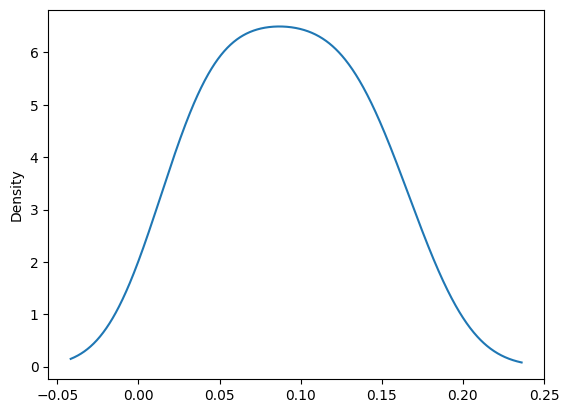

In [46]:
l = [] 
for i in range(1,10000000): 
    l.append(random.randint(1,6) + random.randint(1,6))

s = pd.Series(l).value_counts().sort_index()/len(l)

# print(s)
s.plot(kind = "kde")

<Axes: >

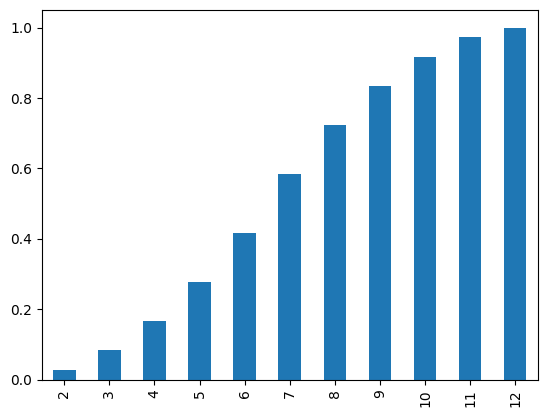

In [47]:
np.cumsum(s).plot(kind = "bar")

In [48]:
import matplotlib.pyplot as plt
from numpy.random import normal



In [49]:
sample = normal(loc = 100 , scale = 10 , size = 1000)
sample = np.sort(sample)

sample

array([ 68.81180807,  70.86205093,  71.92033253,  72.68875793,
        73.01865178,  74.43543069,  74.56138014,  75.1215396 ,
        75.24178217,  75.36269571,  76.60007012,  76.74303126,
        77.61679161,  77.79334121,  77.84191644,  77.94176095,
        78.10163253,  78.29959978,  78.38583317,  78.46039158,
        78.52727723,  78.85948219,  78.94339149,  78.96723881,
        79.23177504,  79.59734362,  79.60869404,  79.74571597,
        79.74966857,  79.86145289,  80.33658165,  80.46144506,
        80.62828166,  80.71245847,  80.78891684,  81.00243988,
        81.17988312,  81.19048023,  81.45357911,  81.52518956,
        81.54945081,  81.68639415,  81.89786136,  81.93528597,
        82.01237573,  82.53313554,  82.68128913,  82.87446802,
        82.88878159,  82.92685415,  83.20239994,  83.22707851,
        83.30299363,  83.34357646,  83.60122696,  83.75641357,
        83.82209334,  83.87396796,  84.003833  ,  84.04302781,
        84.20163191,  84.23345716,  84.36363982,  84.47

(array([  2.,   5.,   8.,  20.,  23.,  43.,  66.,  81.,  95., 133., 117.,
        103., 104.,  66.,  57.,  36.,  19.,  12.,   5.,   5.]),
 array([ 68.81180807,  71.82958348,  74.84735888,  77.86513429,
         80.8829097 ,  83.9006851 ,  86.91846051,  89.93623591,
         92.95401132,  95.97178673,  98.98956213, 102.00733754,
        105.02511295, 108.04288835, 111.06066376, 114.07843916,
        117.09621457, 120.11398998, 123.13176538, 126.14954079,
        129.16731619]),
 <BarContainer object of 20 artists>)

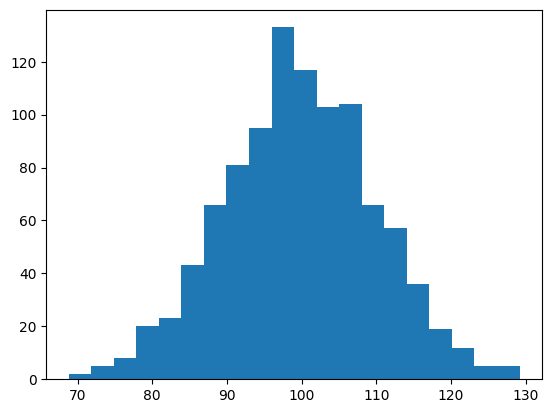

In [50]:
plt.hist(sample , bins = 20)

In [51]:
sample_mean = sample.mean()
sample_std = sample.std()

In [52]:
from scipy.stats import norm

dist = norm(sample_mean , sample_std)

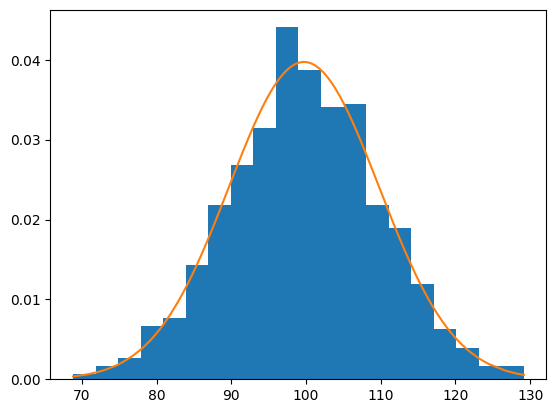

In [53]:
# probabilities = [dist.pdf(value) for value in values]
probabilities = [dist.pdf(value) for value in sample]

plt.hist(sample , bins = 20 , density = True)
plt.plot(sample , probabilities)

plt.show()

In [54]:
sample1 = normal(loc = 40 , scale = 5 , size = 700)
sample2 = normal(loc = 60 , scale = 5 , size = 300)

sample = np.sort(np.hstack((sample1 , sample2)))

sample

array([21.35162883, 23.51047124, 23.97768084, 26.9383831 , 27.54443247,
       27.79568248, 28.39363272, 28.54135217, 28.97602585, 29.44298202,
       29.48523031, 29.5660242 , 29.61855816, 29.69286599, 29.98220206,
       30.2332821 , 30.40559585, 30.44938657, 30.71401449, 30.72767607,
       30.9106235 , 31.08102445, 31.08112518, 31.09016244, 31.48316239,
       31.50949888, 31.56874503, 31.59000042, 31.62636521, 31.6335128 ,
       31.63530149, 31.69005701, 31.72639885, 31.7626349 , 31.7864652 ,
       31.80428324, 32.04471067, 32.07297664, 32.27165943, 32.34849871,
       32.37448226, 32.44239887, 32.49669669, 32.56134533, 32.65308877,
       32.84944738, 32.87087862, 32.87844036, 32.95706725, 32.97265914,
       32.98867216, 33.00802137, 33.08071473, 33.08271879, 33.14746359,
       33.17774923, 33.19910961, 33.26798886, 33.29887618, 33.32925373,
       33.36056958, 33.37722275, 33.38316898, 33.41793896, 33.41922152,
       33.52551797, 33.53777737, 33.54315189, 33.54756113, 33.55

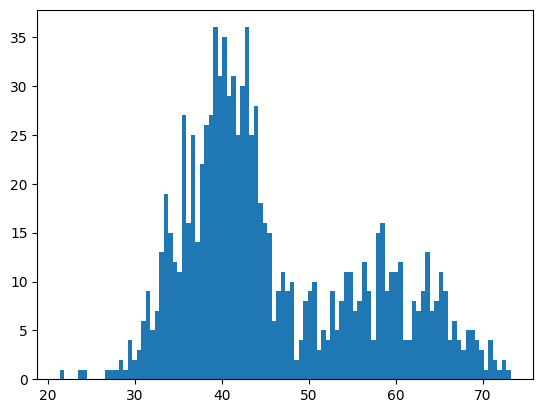

In [55]:
plt.hist(sample , bins = 100)

plt.show()

In [56]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth = 0.5 , kernel = "gaussian")

sample = sample.reshape((len(sample) , 1))

model.fit(sample)

KernelDensity(bandwidth=0.5)

In [57]:
values = np.linspace(sample.min() , sample.max() ,10000)
values = values.reshape((len(values) , 1))

In [58]:
probabilities = model.score_samples(sample)
probabilities = np.exp(probabilities)

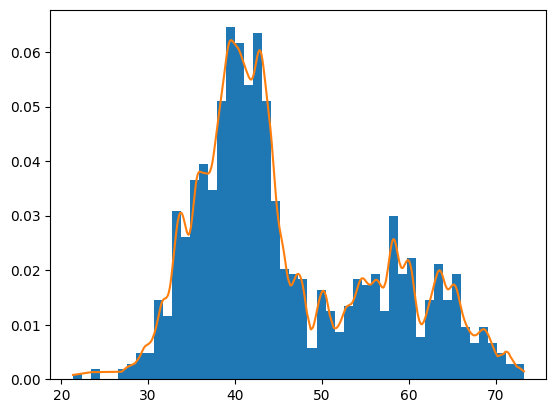

In [59]:
plt.hist(sample , bins = 50 , density = True)
plt.plot(sample , probabilities)

plt.show()

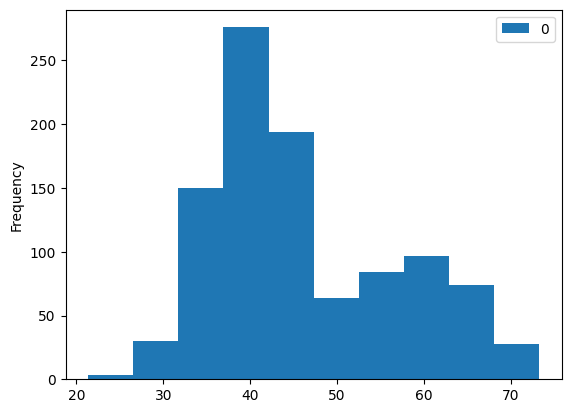

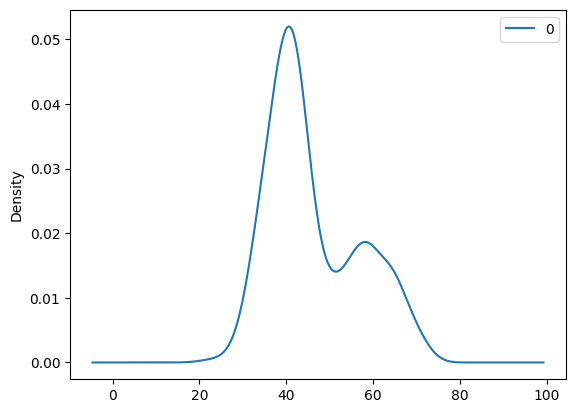

In [60]:
pd.DataFrame(sample).plot(kind = "hist")
pd.DataFrame(sample).plot(kind = "kde")

plt.show()

In [61]:
import seaborn as sns


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

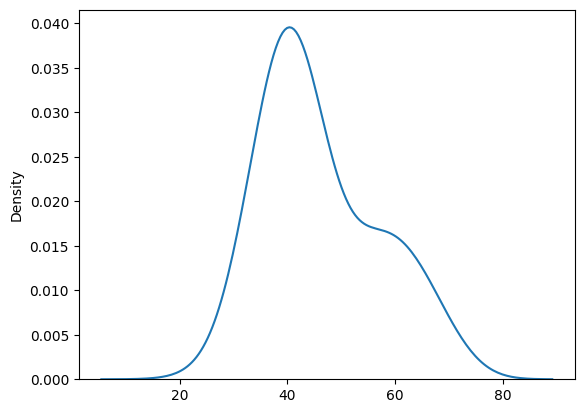

In [62]:
sns.kdeplot(sample.reshape(sample.size) , bw_adjust=2)

In [63]:
df = pd.read_csv("/kaggle/input/iris-dataset/iris.csv")

df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [64]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='sepal_length', ylabel='Density'>

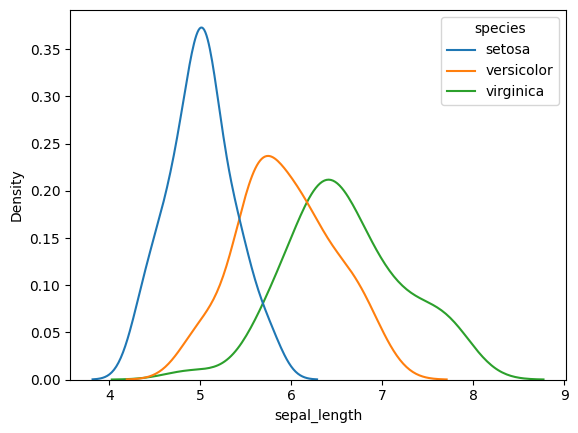

In [65]:
sns.kdeplot(data=df , x=df["sepal_length"] , hue=df["species"])


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='sepal_width', ylabel='Density'>

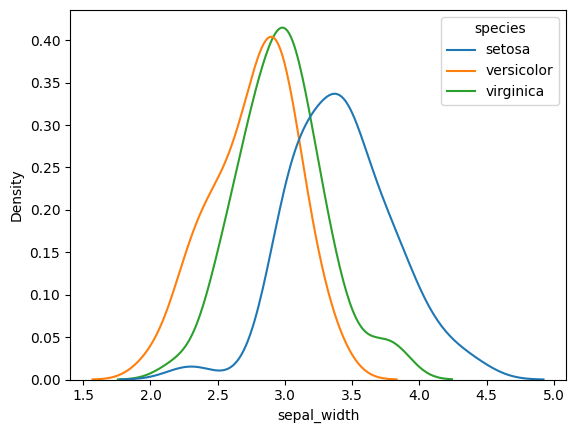

In [66]:
sns.kdeplot(data=df , x=df["sepal_width"] , hue=df["species"])


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='petal_length', ylabel='Density'>

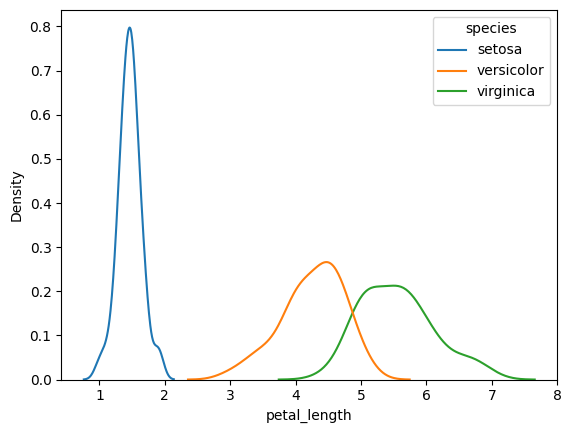

In [67]:
sns.kdeplot(data=df , x=df["petal_length"] , hue=df["species"])


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='petal_width', ylabel='Density'>

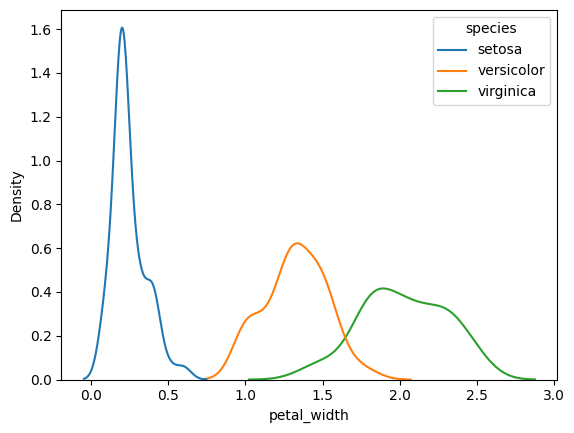

In [68]:
sns.kdeplot(data=df , x=df["petal_width"] , hue=df["species"])


In [69]:
# df = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")
# df

In [70]:
# sns.kdeplot(data=df , x = "Age" , hue=df["Survived"])

KeyError: 'Survived'

In [ ]:
sns.kdeplot(data=df , x=df["petal_width"] , hue=df["species"])
sns.ecdfplot(data=df , x=df["petal_width"] , hue=df["species"])


In [71]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='sepal_length', ylabel='Density'>

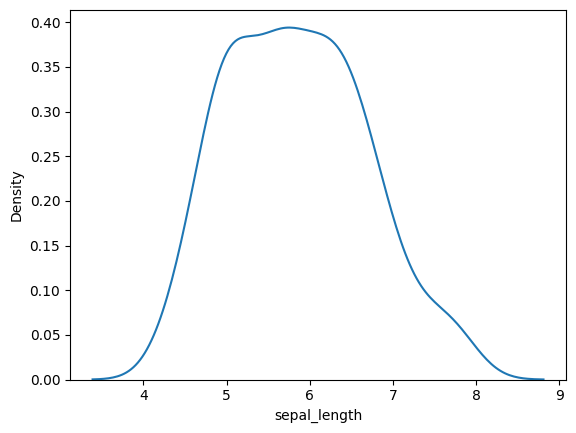

In [72]:
sns.kdeplot(df["sepal_length"])

In [73]:
temp = sorted(df["sepal_length"].tolist())

temp

[4.3,
 4.4,
 4.4,
 4.4,
 4.5,
 4.6,
 4.6,
 4.6,
 4.6,
 4.7,
 4.7,
 4.8,
 4.8,
 4.8,
 4.8,
 4.8,
 4.9,
 4.9,
 4.9,
 4.9,
 4.9,
 4.9,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.2,
 5.2,
 5.2,
 5.2,
 5.3,
 5.4,
 5.4,
 5.4,
 5.4,
 5.4,
 5.4,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.9,
 5.9,
 5.9,
 6.0,
 6.0,
 6.0,
 6.0,
 6.0,
 6.0,
 6.1,
 6.1,
 6.1,
 6.1,
 6.1,
 6.1,
 6.2,
 6.2,
 6.2,
 6.2,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.5,
 6.5,
 6.5,
 6.5,
 6.5,
 6.6,
 6.6,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.8,
 6.8,
 6.8,
 6.9,
 6.9,
 6.9,
 6.9,
 7.0,
 7.1,
 7.2,
 7.2,
 7.2,
 7.3,
 7.4,
 7.6,
 7.7,
 7.7,
 7.7,
 7.7,
 7.9]

In [76]:
y = []

for i in range(1,101):
    y.append(np.percentile(temp , i))

y

[4.4,
 4.4,
 4.547,
 4.6,
 4.6,
 4.694,
 4.743,
 4.8,
 4.8,
 4.8,
 4.9,
 4.9,
 4.9,
 4.9,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.029,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.123,
 5.2,
 5.2,
 5.27,
 5.4,
 5.4,
 5.4,
 5.4,
 5.5,
 5.5,
 5.5,
 5.5,
 5.511,
 5.6,
 5.6,
 5.6,
 5.606999999999999,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.9,
 5.9,
 6.0,
 6.0,
 6.0,
 6.0,
 6.1,
 6.1,
 6.1,
 6.1,
 6.2,
 6.2,
 6.234,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.328,
 6.4,
 6.4,
 6.4,
 6.4,
 6.473000000000001,
 6.5,
 6.5,
 6.5200000000000005,
 6.6,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.763,
 6.8,
 6.8610000000000015,
 6.9,
 6.9,
 7.008000000000001,
 7.156999999999999,
 7.2,
 7.254999999999998,
 7.407999999999999,
 7.6530000000000005,
 7.7,
 7.7,
 7.9]

In [82]:
normal_sample = sorted(np.random.normal(loc=0 , scale=1 , size=10000))

normal_sample

[-3.9980588890322486,
 -3.581176624999743,
 -3.2734804754454165,
 -3.193851074709622,
 -3.193499708306996,
 -3.1865071484824132,
 -3.153024748387254,
 -3.0369138326301854,
 -2.9993131469803607,
 -2.997144677144651,
 -2.95503632002631,
 -2.9324582441247773,
 -2.9303678571564324,
 -2.928889010488806,
 -2.9109284032553173,
 -2.9017361430197357,
 -2.90119964970088,
 -2.87212228729145,
 -2.8677118953464644,
 -2.8541200113490306,
 -2.8181216410101686,
 -2.7843753852511717,
 -2.7747327693903325,
 -2.768074996394041,
 -2.7623585521180836,
 -2.7620519720118444,
 -2.7551251270956607,
 -2.7548617219943745,
 -2.7159294882054468,
 -2.7107426957519465,
 -2.70807583340244,
 -2.705755441276303,
 -2.7045642517478394,
 -2.7029527905014232,
 -2.695893559132951,
 -2.6716562240620694,
 -2.657188494997971,
 -2.6446229625981883,
 -2.6357452155823573,
 -2.6259812574729176,
 -2.6086274159585447,
 -2.5783872860996975,
 -2.5691508468713264,
 -2.5673451038328934,
 -2.5667990553641338,
 -2.5419082397136856,
 -2.53

In [83]:
x = []

for i in range(1,101):
    x.append(np.percentile(normal_sample , i))

x

[-2.338392944520949,
 -2.059214379755287,
 -1.8865385591041322,
 -1.7412426592108539,
 -1.6323203663319885,
 -1.5439829732561214,
 -1.4572134360350713,
 -1.3767740123924868,
 -1.3157106231007,
 -1.2623318130330683,
 -1.2109141715728118,
 -1.1653450254533178,
 -1.1151727835835057,
 -1.0800104371147314,
 -1.0385433902729644,
 -0.9943949859551502,
 -0.9576030411833576,
 -0.911473934020489,
 -0.872283517609187,
 -0.8401438652782371,
 -0.8055557382505413,
 -0.7686297895367071,
 -0.7368666813831009,
 -0.7068735293090416,
 -0.6681870270854665,
 -0.6368495268306504,
 -0.6053946918456771,
 -0.5717666845935336,
 -0.5473768440317313,
 -0.5204887429994437,
 -0.4947398929615832,
 -0.46313143684708824,
 -0.43490097665016514,
 -0.40986267994872505,
 -0.3816227427510296,
 -0.3537865155099687,
 -0.3261222595005137,
 -0.29984573551088056,
 -0.275277275688683,
 -0.24970845488325633,
 -0.2236381421228968,
 -0.19499132460965268,
 -0.16876428091339635,
 -0.14709832165947953,
 -0.12242542575950313,
 -0.09431

<Axes: >

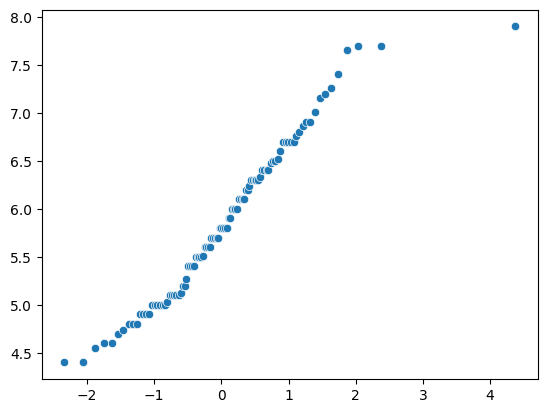

In [85]:
sns.scatterplot(x=x , y=y)